In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
import platform

# 1. 운영체제별 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')
elif platform.system() == 'Darwin': # Mac OS
    plt.rc('font', family='AppleGothic')
else: # Linux (Colab 등)
    plt.rc('font', family='NanumBarunGothic')

# 2. 마이너스 기호(-) 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

In [4]:
base_path = r"/Users/kdt_0900_lyn/ml/resoce/dataset"
file_name = r"banknote_authentication.csv"
file_path = os.path.join(base_path, file_name)

In [6]:
bank_df = pd.read_csv(file_path)
bank_df

,variance,skewness,curtosis,entropy,class
0,3.62160,8.66610,-2.8073,-0.44699,0
1,4.54590,8.16740,-2.4586,-1.46210,0
2,3.86600,-2.63830,1.9242,0.10645,0
3,3.45660,9.52280,-4.0112,-3.59440,0
4,0.32924,-4.45520,4.5718,-0.98880,0
...,...,...,...,...,...
1367,0.40614,1.34920,-1.4501,-0.55949,1
1368,-1.38870,-4.87730,6.4774,0.34179,1
1369,-3.75030,-13.45860,17.5932,-2.77710,1
1370,-3.56370,-8.38270,12.3930,-1.28230,1


## SVM
- Banknote Authentication 데이터셋은 진짜 지폐와 위조 지폐 이미지를 복잡하고 일그러진 이미지(또는 신호)를 작은 물결 모양의 조각(Wavelet)들로 쪼개서,  
  눈에 잘 안 보이는 패턴 특징을 뽑아내는 기술 웨이블릿 변환하여 추출한 4가지 연속형 특성으로 구성된 이진 분류 데이터입니다.

[Banknote Authentication 데이터셋](https://archive.ics.uci.edu/dataset/267/banknote+authentication)

### 데이터셋 컬럼 명세 (Metadata)

| 컬럼명 | 데이터 타입 | 데이터 범위 (Min ~ Max) | 구분 | 설명 |
| :--- | :---: | :---: | :---: | :--- |
| **variance** | `float64` | -7.0421 ~ 6.8248 | Feature | 웨이블릿 변환 이미지의 변량 (지폐 선명도 및 질감 변동 폭) |
| **skewness** | `float64` | -13.7731 ~ 12.9516 | Feature | 웨이블릿 변환 이미지의 왜도 (명암 분포의 비대칭성) |
| **curtosis** | `float64` | -5.2861 ~ 17.9274 | Feature | 웨이블릿 변환 이미지의 첨도 (명암 분포의 돌출도) |
| **entropy** | `float64` | -8.5801 ~ 2.4495 | Feature | 이미지 정보의 엔트로피 (무작위성 및 정보 복잡도) |
| **class** | `int64` | 0 또는 1 | Target | 지폐 진위 여부 (**0**: 진짜 지폐 / **1**: 위조 지폐) |

### 데이터셋의 상세 설명
- variance (변량): 미세 질감이 얼마나 일정하게 오르락내리락하는가? (지폐 질감 선명도)
- skewness (왜도): 명암이나 잉크 굵기 패턴이 한쪽으로 쏠려 있는가?
- curtosis (첨도): 잉크 경계선이나 미세 선들이 얼마나 뾰족하고 매섭게 인쇄되었는가?
- entropy (엔트로피): 미세 패턴이 얼마나 복잡하고 무작위적인가?

## 1단계 데이터분석 

In [8]:
bank_df.describe()
# 이상치로 판단 XX (가능성이 있기 떄문)   - 1번째로는 판단하기

,variance,skewness,curtosis,entropy,class
count,1372.000000,1372.000000,1372.000000,1372.000000,1372.000000
mean,0.433735,1.922353,1.397627,-1.191657,0.444606
std,2.842763,5.869047,4.310030,2.101013,0.497103
min,-7.042100,-13.773100,-5.286100,-8.548200,0.000000
25%,-1.773000,-1.708200,-1.574975,-2.413450,0.000000
50%,0.496180,2.319650,0.616630,-0.586650,0.000000
75%,2.821475,6.814625,3.179250,0.394810,1.000000
max,6.824800,12.951600,17.927400,2.449500,1.000000


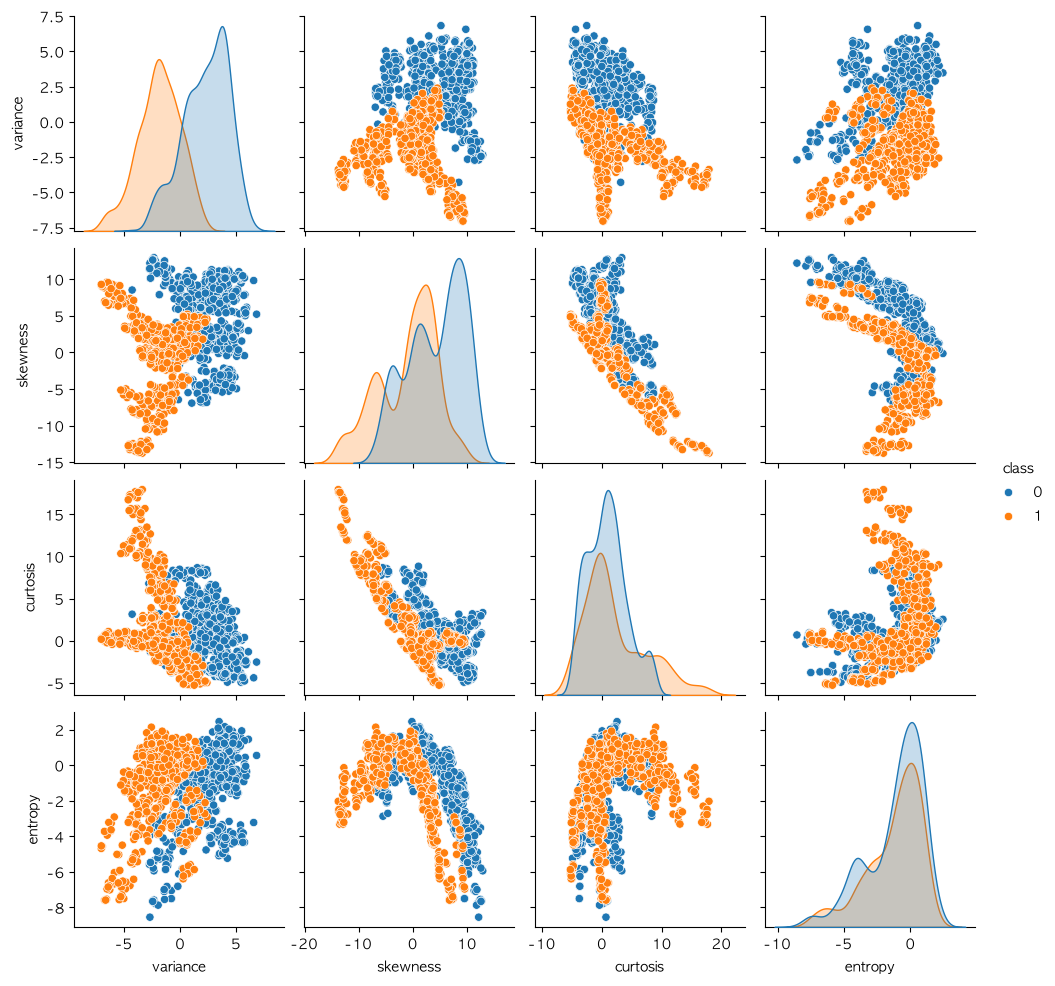

In [11]:
sns.pairplot(bank_df, hue="class")
plt.show()

In [15]:
X = bank_df.drop("class", axis=1)   # 특성 여러개 (4개 )0-> 대문자 
X.head()

,variance,skewness,curtosis,entropy
0,3.62160,8.6661,-2.8073,-0.44699
1,4.54590,8.1674,-2.4586,-1.46210
2,3.86600,-2.6383,1.9242,0.10645
3,3.45660,9.5228,-4.0112,-3.59440
4,0.32924,-4.4552,4.5718,-0.98880


In [20]:
y = bank_df["class"]
y.head()

0    0
1    0
2    0
3    0
4    0
Name: class, dtype: int64

## 3단계 , 데이터 분할 

In [19]:
from sklearn.model_selection import train_test_split

In [22]:
X_train, X_test, y_train, y_test =  train_test_split(X, y, test_size=0.2, random_state=2026, stratify=y)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(1097, 4) (275, 4) (1097,) (275,)


## 표준화 또는 정규화
- scikit-learn의 preprocessing 모듈
    - 데이터 전처리는 많은 작업들을 하게 되는데 대표적인 것이 scaling이다.
    데이터의 feature scaling이라고 한다.
    이 것은 크게 두가지 방법이 있는데
        1. 표준화 (standardization)
            - 평균을 기준으로 표준 편차만큼 동등하게 변경
        2. 정규화 (nomalization)
             0 ~ 1사이의 값으로 변경
    정규화와 표준화는 모두 머신러닝 알고리즘을 훈련시키는데 있어서 사용되는 특성(feature)들이  
    '모두 비슷한 영향력'을 행사하도록 값을 변환해주는 전처리 기술이다.


In [25]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

# .fit_transform: 평균과 표준ㅎ편차를 모두 구하고 표준화
X_train_scaled = scaler.fit_transform(X_train)
# .transform : 구해진 평균과 표준편차를 이용해서 표준화 
X_test_scaled = scaler.transform(X_test)


In [28]:
# 같은 데이터 
print(X_train.loc[780])
print(X_train_scaled[1])   # 단위가 줄어듬 -> 값 영행력을 맞춤 

variance    -3.5801
skewness   -12.9309
curtosis    13.1779
entropy     -2.5677
Name: 780, dtype: float64
[-1.41012125 -2.5246267   2.73858777 -0.63924813]


## 4단계 , 모델 준비 

In [34]:
from sklearn.svm import SVC

In [35]:
svc  = SVC()

## 5단계 , 모델 학습 

In [37]:
svc.fit(X_train_scaled, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


## 6단계 , 모델 예측


In [39]:

y_pred = svc.predict(X_test_scaled)
# 예측값
print(y_pred)
# 정답지 
print(list(y_test))

[1 1 0 0 0 1 1 1 1 1 0 0 0 0 1 0 1 0 1 0 1 0 0 0 0 0 0 1 1 0 0 1 0 0 1 0 0
 0 1 0 1 1 0 1 0 0 0 1 0 1 1 1 0 1 0 0 0 1 0 1 1 0 1 0 1 0 0 1 0 0 1 0 1 0
 0 1 0 0 1 0 0 0 0 0 1 0 0 1 1 0 0 0 0 0 1 1 0 0 0 1 0 0 1 0 0 0 0 0 1 1 1
 0 1 1 1 1 1 0 1 0 0 1 1 0 0 0 0 0 0 0 1 0 1 0 0 1 1 1 1 1 0 1 1 1 0 0 0 0
 1 1 1 0 0 0 0 0 1 0 1 1 1 1 1 0 1 1 1 1 0 1 0 1 0 0 1 0 1 1 0 0 1 1 1 1 0
 0 0 1 0 0 0 1 0 1 0 1 1 1 1 0 1 1 0 0 0 0 1 1 1 0 0 0 0 0 0 1 1 1 1 1 0 1
 0 0 1 1 1 0 0 1 1 0 1 0 1 0 1 0 1 1 1 1 1 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0
 0 0 0 1 1 0 1 0 0 1 0 0 0 0 1 0]
[1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0,

In [42]:

y_pred = svc.predict(X_test_scaled)
# 예측값
print(y_pred[:10])
# 정답지 
print(list(y_test)[:10])

[1 1 0 0 0 1 1 1 1 1]
[1, 1, 0, 0, 0, 1, 1, 1, 1, 1]


## 6단계  모델 평가


In [43]:
svc.score(X_train_scaled, y_train)


1.0

In [45]:
svc.score(X_test_scaled, y_test)

1.0